## Massive Pipeline Example 

In [1]:
%load_ext autoreload
%autoreload 2

import datetime
import polars as pl
from spectral.data import massive
from spectral.quant import Portfolio

pl.Config.set_tbl_rows(n=10)
pl.Config.set_tbl_rows(n=20)

EQUITIES = ["AAPL", "MSFT", "NVDA", "GOOG", "AMZN", "META", "TSLA"]
BENCHMARK = ["I:NDX"]

#### Get Daily Bar Data

In [16]:
df = massive.get_aggregate_bars( 
    tickers=EQUITIES + BENCHMARK,
    multiplier=1,
    timespan="day",
    from_=datetime.date(year=2024, month=1, day=1),
    to=datetime.date(year=2025, month=10, day=13)
)

In [17]:
# filter on business days only given indexes sometimes have data on the weekends. This only works because data is from one single calendar (US)
df = df.filter(pl.col("timestamp").dt.weekday() < 5)

In [18]:
from datetime import date

start_d = date(2024, 10, 1)
end_d   = date(2024, 10, 10)

(
    df
    # .filter(pl.col("timestamp").dt.weekday() < 5)  # drop weekends if you want
    .filter(pl.col("timestamp").dt.date().is_between(start_d, end_d))
    .collect()
    .pivot(index="timestamp", on="ticker", values="close")
    .sort("timestamp")
)


timestamp,AAPL,MSFT,NVDA,GOOG,AMZN,META,TSLA,I:NDX
"datetime[ms, America/New_York]",f64,f64,f64,f64,f64,f64,f64,f64
2024-10-01 00:00:00 EDT,226.21,420.69,117.0,168.42,185.13,576.47,258.02,19773.302652
2024-10-02 00:00:00 EDT,226.78,417.13,118.85,167.31,184.76,572.81,249.02,19802.584797
2024-10-03 00:00:00 EDT,225.67,416.54,122.85,167.21,181.96,582.77,240.66,19793.342885
2024-10-07 00:00:00 EDT,221.69,409.54,127.72,164.39,180.8,584.78,240.83,19800.739536
2024-10-08 00:00:00 EDT,225.77,414.71,132.89,165.7,182.72,592.89,244.5,20107.776734
2024-10-09 00:00:00 EDT,229.54,417.46,132.65,163.06,185.17,590.51,241.05,20268.859058
2024-10-10 00:00:00 EDT,229.04,415.84,134.81,163.18,186.65,583.83,238.77,20241.76101


#### Returns

In [19]:
# Compute returns
df = df.with_columns([
    pl.col("close").quant.returns(periods=1, over="ticker")
])

# Compound returns
_df = df.with_columns([
    pl.col("return").quant.compound(over="ticker").alias(f"compounded_return")
])

# Collect to eager DataFrame and pivot
_compounded_returns_df = (
    _df.collect()
    .pivot(
        
        index="timestamp",
        on="ticker",
        values="compounded_return"
    )
    .sort("timestamp")
)

# Plot
_compounded_returns_df.bokeh.plot(title="Compounded Returns", x_col="timestamp");

#### Rolling Total Vol

In [20]:
# Compute rolling volatility
df = df.with_columns([
    pl.col("return").quant.rolling_vol(window_size=90, min_samples=90, over="ticker")
])

# Collect to eager DataFrame and pivot
_vol_df = (
    df.collect()
    .pivot(
        index="timestamp",
        on="ticker",
        values="rolling_vol"
    )
    .sort("timestamp")
)

# Plot
_vol_df.bokeh.plot(title="Rolling Vol.", x_col="timestamp");

#### Rolling Betas

In [21]:
# Separate and merge benchmark returns
benchmark_returns_df = (
    df.filter(pl.col("ticker") == BENCHMARK[0])
    .select(["timestamp", "return"])
    .rename({"return": "benchmark_return"})
)
df = df.join(other=benchmark_returns_df, on="timestamp", how="inner")

# Compute rolling beta
df = df.with_columns([
    pl.col("return").quant.rolling_beta(benchmark_col=pl.col("benchmark_return"), window_size=90, over="ticker")
])

# Collect to eager DataFrame and pivot
_betas_df = (
    df.collect()
    .pivot(
        index="timestamp",
        on="ticker",
        values="rolling_beta"
    )
    .sort("timestamp")
)

# Plot
_betas_df.bokeh.plot(title="Rolling Betas.", x_col="timestamp");

#### Idiosyncratic Returns

In [22]:
# Compute systematic and idiosyncratic returns
df = df.with_columns(
    (pl.col("rolling_beta") * pl.col("benchmark_return")).alias("systematic_return")
)
df = df.with_columns(
    (pl.col("return") - pl.col("systematic_return")).alias("idio_return")
)

# Compound returns
_df = df.with_columns([
    pl.col("systematic_return").quant.compound(over="ticker").alias(f"compounded_systematic_return")
])
_df = _df.with_columns([
    pl.col("idio_return").quant.compound(over="ticker").alias(f"compounded_idio_return")
])

# Collect to eager DataFrame and pivot
_systematic_returns_df = (
    _df.collect()
    .pivot(
        index="timestamp",
        on="ticker",
        values="compounded_systematic_return"
    )
    .sort("timestamp")
)
_idio_returns_df = (
    _df.collect()
    .pivot(
        index="timestamp",
        on="ticker",
        values="compounded_idio_return"
    )
    .sort("timestamp")
)

# Plot
_systematic_returns_df.bokeh.plot(title="Systematic Returns", x_col="timestamp");

In [9]:
_idio_returns_df.bokeh.plot(title="Idio. Returns", x_col="timestamp");

#### Rolling Vol.

In [10]:
# Compute rolling systematic, idio, and total volatility
df = df.with_columns([
    pl.col("systematic_return")
        .quant.rolling_vol(over="ticker", window_size=90, min_samples=90)
        .alias("rolling_systematic_vol"),

    pl.col("idio_return")
        .quant.rolling_vol(over="ticker", window_size=90, min_samples=90)
        .alias("rolling_idio_vol"),

    pl.col("return")
        .quant.rolling_vol(over="ticker", window_size=90, min_samples=90)
        .alias("rolling_total_vol"),
])

# Collect to eager DataFrame and pivot
_systematic_vol_df = (
    df.collect()
    .pivot(
        index="timestamp",
        on="ticker",
        values="rolling_systematic_vol"
    )
    .sort("timestamp")
)
_idio_vol_df = (
    df.collect()
    .pivot(
        index="timestamp",
        on="ticker",
        values="rolling_idio_vol"
    )
    .sort("timestamp")
)
_idio_total_df = (
    df
    .filter(pl.col("systematic_return").is_not_null())
    .collect()
    .pivot(
        index="timestamp",
        on="ticker",
        values="rolling_total_vol"
    )
    .sort("timestamp")
)

# Plot
_systematic_vol_df.bokeh.plot(title="Rolling Systematic Vol.", x_col="timestamp");

In [11]:
_idio_vol_df.bokeh.plot(title="Rolling Idio. Vol.", x_col="timestamp");

In [12]:
_idio_total_df.bokeh.plot(title="Rolling Total Vol.", x_col="timestamp");

#### Portfolio Stats

In [ ]:
portfolio = Portfolio(
    df=df, 
    portfolio={"AAPL": 0.25, "IBM": 0.50, "AMZN": 0.15, "MSFT": 0.10}, 
    benchmark=BENCHMARK[0]
)
portfolio_returns = portfolio.compute_returns()

In [ ]:
p_ret = portfolio_returns.collect().to_pandas()
p_ret.set_index(keys="timestamp", inplace=True)
p_ret.drop(columns="benchmark_return", inplace=True)

<Axes: xlabel='timestamp'>

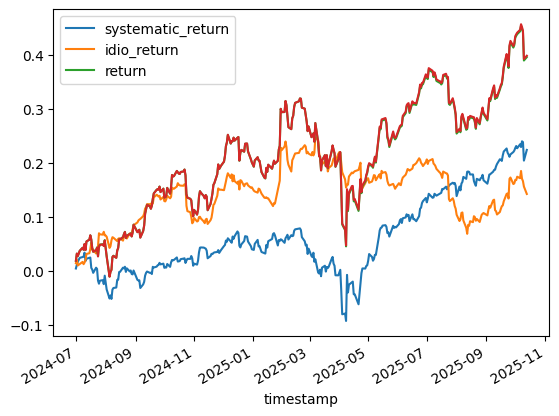

In [ ]:
ax = p_ret.loc["2024-07":].add(1).cumprod().sub(1).plot()
(p_ret.loc["2024-07":, "idio_return"].add(1).cumprod() * p_ret.loc["2024-07":, "systematic_return"].add(1).cumprod()).sub(1).plot(ax=ax)

<Axes: xlabel='timestamp'>

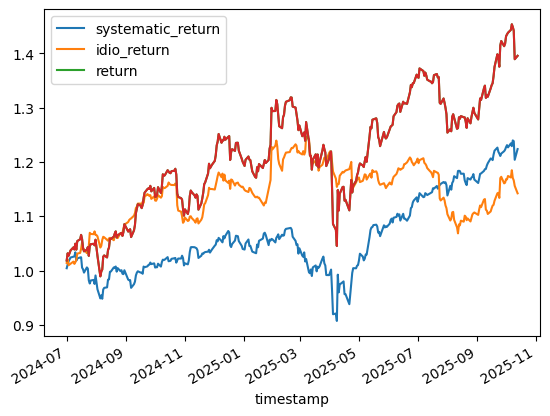

In [ ]:
ax = p_ret.loc["2024-07":].add(1).cumprod().plot()
(p_ret.loc["2024-07":, "idio_return"] + p_ret.loc["2024-07":, "systematic_return"]).add(1).cumprod().plot(ax=ax)